<a href="https://colab.research.google.com/github/tecnojimbo/G5-ANALISISDATOS-EDA-/blob/dev-janzules/G5-AnalisisDatos-EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reporte Ejecutivo: Segmentación de Clientes Utilizando Análisis RFM

## Resumen Ejecutivo

Este reporte presenta un análisis exhaustivo de la base de clientes de la empresa utilizando la metodología RFM (Recencia, Frecuencia, Monetario). El objetivo principal es segmentar a los clientes en grupos homogéneos basados en su comportamiento de compra, lo que permitirá implementar estrategias de marketing más efectivas y personalizadas. Hemos identificado cinco segmentos clave: 'Campeones', 'Clientes Leales', 'Leales Potenciales', 'En Riesgo' y 'Clientes Perdidos', cada uno con características distintivas en términos de actividad y valor. Las visualizaciones y métricas detalladas a continuación ofrecen una visión clara del perfil de cada segmento y resaltan oportunidades para la retención y el crecimiento.

## 1. Carga y Preparación de Datos

El primer paso crucial en cualquier análisis es la carga y limpieza de los datos. Se cargaron los datos de ventas y se realizaron varias transformaciones para asegurar la calidad y el formato adecuado para el análisis RFM.

### 1.1. Importación de Librerías y Carga Inicial

---



In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

customerData = pd.read_csv('/content/Analytical Customer Segmentation Analysis(in).csv', encoding='latin1')

### 1.2. Exploración Inicial de Datos

---



In [6]:
print('Primeras 5 filas:')
display(customerData.head(5))

print('\nÚltimas 5 filas:')
display(customerData.tail(5))

print('\nValores nulos por columna:')
display(customerData.isnull().sum())

print('\nTipos de datos actuales:')
display(customerData.info())

Primeras 5 filas:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,01/12/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,01/12/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,01/12/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,01/12/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,01/12/2010 08:26,3.39,17850.0,United Kingdom



Últimas 5 filas:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12.0,09/12/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,09/12/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4.0,09/12/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4.0,09/12/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3.0,09/12/2011 12:50,4.95,12680.0,France



Valores nulos por columna:


,0
InvoiceNo,0
StockCode,6035
Description,7489
Quantity,6035
InvoiceDate,6035
UnitPrice,6035
CustomerID,138727
Country,6035



Tipos de datos actuales:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    535874 non-null  object 
 2   Description  534420 non-null  object 
 3   Quantity     535874 non-null  float64
 4   InvoiceDate  535874 non-null  object 
 5   UnitPrice    535874 non-null  float64
 6   CustomerID   403182 non-null  float64
 7   Country      535874 non-null  object 
dtypes: float64(3), object(5)
memory usage: 33.1+ MB


None

### 1.3. Limpieza y Transformación de Datos
Se eliminaron filas con valores nulos críticos y con cantidades/precios no válidos. Posteriormente, se convirtieron los tipos de datos de `InvoiceDate` y `CustomerID` para permitir cálculos temporales y asegurar la integridad de los identificadores. Además, se creó la columna `TotalPrice`.

---



In [8]:
# Eliminar filas con 'CustomerID' o 'Description' faltantes
customerData.dropna(subset=['CustomerID', 'Description'], inplace=True)

# Eliminar filas donde 'Quantity' o 'UnitPrice' son menores o iguales a 0
customerData = customerData[customerData['Quantity'] > 0]
customerData = customerData[customerData['UnitPrice'] > 0]

print('DataFrame después de manejar nulos y cantidades/precios inválidos:')
display(customerData.head())

print('\nNueva forma del DataFrame:', customerData.shape)
print('Valores nulos por columna después de la limpieza:')
display(customerData.isnull().sum())

# Convertir InvoiceDate a datetime
customerData['InvoiceDate'] = pd.to_datetime(customerData['InvoiceDate'], dayfirst=True)

# Convertir CustomerID a tipo entero
customerData['CustomerID'] = customerData['CustomerID'].astype(int)

# Crear la columna TotalPrice
customerData['TotalPrice'] = customerData['Quantity'] * customerData['UnitPrice']

print('\nDataFrame después de las conversiones de tipo y la creación de nuevas características:')
display(customerData.head())

print('\nNuevos tipos de datos:')
display(customerData.info())

DataFrame después de manejar nulos y cantidades/precios inválidos:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34



Nueva forma del DataFrame: (394303, 9)
Valores nulos por columna después de la limpieza:


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
TotalPrice,0



DataFrame después de las conversiones de tipo y la creación de nuevas características:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34



Nuevos tipos de datos:
<class 'pandas.core.frame.DataFrame'>
Index: 394303 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    394303 non-null  object        
 1   StockCode    394303 non-null  object        
 2   Description  394303 non-null  object        
 3   Quantity     394303 non-null  float64       
 4   InvoiceDate  394303 non-null  datetime64[ns]
 5   UnitPrice    394303 non-null  float64       
 6   CustomerID   394303 non-null  int64         
 7   Country      394303 non-null  object        
 8   TotalPrice   394303 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.1+ MB


None

## 2. Análisis RFM (Recencia, Frecuencia, Monetario)

El análisis RFM es una técnica de segmentación de clientes que utiliza tres métricas clave:

*   **Recencia (R):** ¿Hace cuánto tiempo fue la última compra del cliente?
*   **Frecuencia (F):** ¿Con qué frecuencia compra el cliente?
*   **Monetario (M):** ¿Cuánto dinero gasta el cliente?

Estas métricas nos permiten entender el comportamiento de compra de cada cliente y agruparlos según su valor.

---



### 2.1. Cálculo de la Fecha de Instantánea

Para calcular la Recencia, necesitamos definir una 'fecha de instantánea', que es el día posterior a la última transacción en el conjunto de datos.

---


In [9]:
# Calcular la fecha de instantánea para el análisis RFM
snapshot_date = customerData['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Fecha de Instantánea para el Análisis RFM: {snapshot_date}")

Fecha de Instantánea para el Análisis RFM: 2011-12-10 12:50:00


### 2.2. Cálculo de Recencia, Frecuencia y Monetario

---


In [10]:
rfm = customerData.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda date: (snapshot_date - date.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

display(rfm.head())

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4299.80
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


### 2.3. Asignación de Puntuaciones RFM (Quintiles)

Para estandarizar las métricas RFM, se asignan puntuaciones del 1 al 5 utilizando quintiles. Para Recencia, se invierte la puntuación para que un valor más bajo (más reciente) reciba una puntuación más alta. Para Frecuencia y Monetario, una puntuación más alta indica un mejor desempeño.

---


In [12]:
# Crear segmentos RFM usando quintiles

# Manejar Recencia (un valor más bajo es mejor, puntuación más alta)
r_categories = pd.qcut(rfm['Recency'], 5, duplicates='drop')
r_scores_raw = r_categories.cat.codes
# Invertir puntuaciones: el código raw más alto se mapea a la puntuación más alta (ej. 5)
max_r_score_raw = len(r_categories.cat.categories) - 1
rfm['R_Score'] = max_r_score_raw - r_scores_raw + 1

# Manejar Frecuencia (un valor más alto es mejor, puntuación más alta)
f_categories = pd.qcut(rfm['Frequency'], 5, duplicates='drop')
rfm['F_Score'] = f_categories.cat.codes + 1 # Puntuaciones de 1 a k (número real de bins)

# Manejar Monetario (un valor más alto es mejor, puntuación más alta)
m_categories = pd.qcut(rfm['Monetary'], 5, duplicates='drop')
rfm['M_Score'] = m_categories.cat.codes + 1 # Puntuaciones de 1 a k (número real de bins)

# Concatenar puntuaciones RFM para crear un segmento RFM
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Mostrar las primeras filas con las nuevas puntuaciones y segmentos RFM
display(rfm.head())

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment
0,12346,326,1,77183.60,1,1,5,115
1,12347,2,7,4299.80,5,4,5,545
2,12348,75,4,1797.24,2,3,4,234
3,12349,19,1,1757.55,4,1,4,414
4,12350,310,1,334.40,1,1,2,112


## 3. Segmentación de Clientes RFM

Con las puntuaciones RFM calculadas, se definieron segmentos de clientes basados en combinaciones lógicas de estas puntuaciones. Esto permite categorizar a los clientes en grupos con necesidades y comportamientos similares.

---



In [17]:
# Función para asignar etiquetas a los segmentos RFM
def rfm_level(df):
    if df['R_Score'] >= 4 and df['F_Score'] >= 4 and df['M_Score'] >= 4:
        return 'Campeones'
    elif df['R_Score'] >= 4 and df['F_Score'] >= 2 and df['M_Score'] >= 4:
        return 'Clientes Leales'
    elif df['R_Score'] >= 3 and df['F_Score'] >= 3 and df['M_Score'] >= 3:
        return 'Leales Potenciales'
    elif df['R_Score'] >= 2 and df['F_Score'] >= 2 and df['M_Score'] >= 2:
        return 'En Riesgo'
    else:
        return 'Clientes Perdidos'

# Aplicar la función para crear la columna 'RFM_Level'
rfm['RFM_Level'] = rfm.apply(rfm_level, axis=1)

# Mostrar el recuento de clientes por nivel RFM
print('Recuento de clientes por nivel RFM:')
display(rfm['RFM_Level'].value_counts())

# Calcular el promedio de Recencia, Frecuencia y Monetario por nivel RFM
rfm_level_averages = rfm.groupby('RFM_Level')[['Recency', 'Frequency', 'Monetary']].mean().reset_index()

# Mostrar los promedios por nivel RFM
print('\nPromedios RFM por nivel de cliente:')
display(rfm_level_averages.sort_values(by='Recency'))

Recuento de clientes por nivel RFM:


,count
RFM_Level,
Clientes Perdidos,2437
Campeones,572
En Riesgo,517
Clientes Leales,446
Leales Potenciales,364



Promedios RFM por nivel de cliente:


,RFM_Level,Recency,Frequency,Monetary
0,Campeones,11.090909,15.409091,8615.127360
1,Clientes Leales,15.706278,4.491031,2106.526368
4,Leales Potenciales,40.252747,5.810440,2185.380442
3,En Riesgo,75.924565,3.810445,1277.274025
2,Clientes Perdidos,137.121871,1.485023,560.549004


## 4. Visualizaciones y Análisis de Segmentos

Las siguientes visualizaciones ofrecen una comprensión más profunda de la composición de los segmentos y sus características clave.

### 4.1. Distribución de Clientes por Nivel RFM

Este gráfico de barras muestra la cantidad de clientes en cada uno de los segmentos RFM definidos, ofreciendo una visión general de la distribución de la base de clientes.

---


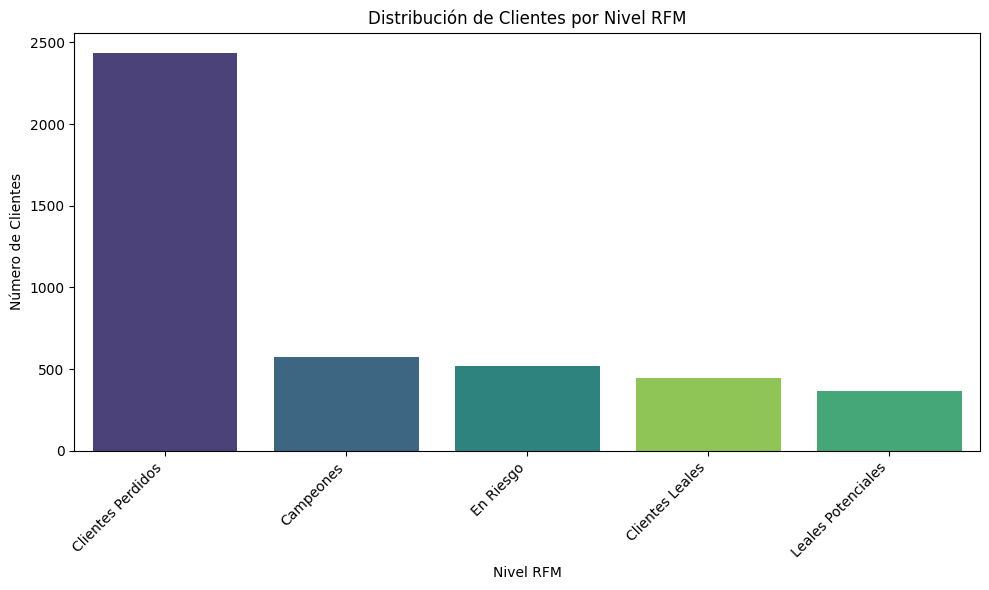

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(x='RFM_Level', data=rfm, palette='viridis', order=rfm['RFM_Level'].value_counts().index, hue='RFM_Level', legend=False)
plt.title('Distribución de Clientes por Nivel RFM')
plt.xlabel('Nivel RFM')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()